<a href="https://colab.research.google.com/github/nagashreesdharwadkar/Diabetes-Prediction-using-Machine-Learning/blob/main/Diabetes_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Dependencies

In [ ]:
import numpy as np # Import NumPy library for numerical operations
import pandas as pd # Import Pandas library for data manipulation and analysis
from sklearn.preprocessing import StandardScaler # Import StandardScaler for feature standardization
from sklearn.model_selection import train_test_split # Import train_test_split to split dataset into training and testing sets
from sklearn import svm # Import Support Vector Machine (SVM) algorithm
from sklearn.metrics import accuracy_score # Import accuracy_score to evaluate model performance
import matplotlib.pyplot as plt # Import the Matplotlib pyplot library for creating graphs and visualizations


Data Collection and Analysis

PIMA Diabetes Dataset


In [ ]:
# Load the PIMA Diabetes dataset into a Pandas DataFrame
diabetes_dataset = pd.read_csv('/content/diabetes.csv')

In [ ]:
# Display the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Display the number of rows and columns in the dataset
diabetes_dataset.shape

(768, 9)

In [ ]:
# Display statistical summary (count, mean, std, min, max,...)
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Count the number of diabetic (1) and non-diabetic (0) patients
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


0 --> Non-Diabetic

1 --> Diabetic

In [ ]:
# Calculate the average values of each feature grouped by Outcome
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


Separating Features and Target Variable


In [ ]:
# Remove the 'Outcome' column and store the remaining columns as input features
X = diabetes_dataset.drop(columns = 'Outcome', axis=1)
# Store the 'Outcome' column as the target/output variable
Y = diabetes_dataset['Outcome']

In [ ]:
# Print the feature dataset
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
# Print the target values
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Data Standardization

In [ ]:
# Create an object of StandardScaler
scaler = StandardScaler()

In [ ]:
# Compute the mean and standard deviation of the training data
scaler.fit(X)

StandardScaler()

In [ ]:
# Display the parameters used by StandardScaler
print(scaler.get_params())

{'copy': True, 'with_mean': True, 'with_std': True}


In [ ]:
# Standardize the feature values
standardized_data = scaler.transform(X)

In [ ]:
# Display the standardized feature values
print(standardized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [ ]:
# Replace original feature values with standardized values
X = standardized_data
# Assign target values again
Y = diabetes_dataset['Outcome']

In [ ]:
# Display standardized feature data
print(X)
# Display target values
print(Y)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Splitting Dataset into Training and Testing Sets

In [ ]:
# Split dataset into 80% training data and 20% testing data
# stratify=Y ensures equal class distribution
# random_state=2 gives reproducible results
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=2)

In [ ]:
# Print the shapes of original, training, and testing datasets
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


Training the Model

In [ ]:
# Create the Support Vector Machine classifier with Linear Kernel
classifier = svm.SVC(kernel='linear')

In [ ]:
# Train the SVM model using training data
classifier.fit(X_train, Y_train)

SVC(kernel='linear')

In [ ]:
# Display the model parameters
print(classifier.get_params())

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


Model Evaluation

To Find Accuracy Score

In [ ]:
# Predict the output for training data
X_train_prediction = classifier.predict(X_train)
# Calculate training accuracy
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [ ]:
# Display training accuracy
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.7866449511400652


In [ ]:
# Predict the output for testing data
X_test_prediction = classifier.predict(X_test)
# Calculate testing accuracy
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [ ]:
# Display testing accuracy
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.7727272727272727


Making a Predictive System

In [ ]:
# Import warnings module
import warnings

# Ignore warning messages
warnings.filterwarnings("ignore")

# Enter sample patient data
# (Pregnancies, Glucose, BloodPressure, SkinThickness,Insulin, BMI, DiabetesPedigreeFunction, Age)
input_data = (5,166,72,19,175,25.8,0.587,51)

# Convert input tuple into NumPy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshape array because the model expects 2D input
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# Standardize the input data using the same scaler
std_data = scaler.transform(input_data_reshaped)

# Display standardized input values
print(std_data)

# Predict whether the patient is diabetic or not
prediction = classifier.predict(std_data)
# Display prediction result (0 or 1)
print(prediction)

# Check prediction result
if (prediction[0] == 0):
  # Output if prediction is 0
  print('The person is not diabetic')
else:
  # Output if prediction is 1
  print('The person is diabetic')

[[ 0.3429808   1.41167241  0.14964075 -0.09637905  0.82661621 -0.78595734
   0.34768723  1.51108316]]
[1]
The person is diabetic


Visualizing the Distribution of Diabetic and Non-Diabetic Patients

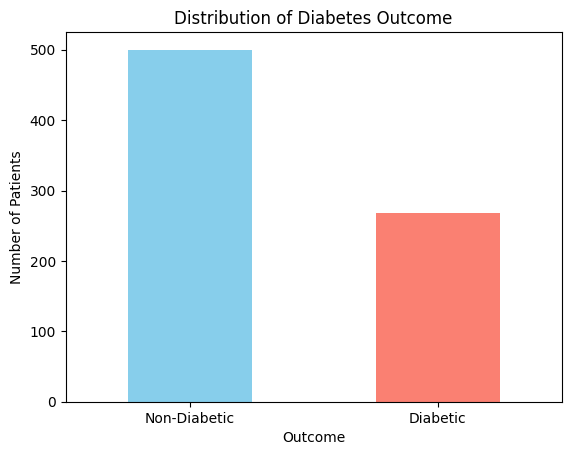

In [ ]:
# Count the number of diabetic and non-diabetic patients
diabetes_dataset['Outcome'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'salmon']
)

# Add a title to the graph
plt.title('Distribution of Diabetes Outcome')
# Label the X-axis
plt.xlabel('Outcome')
# Label the Y-axis
plt.ylabel('Number of Patients')

# Rename the X-axis categories
# 0 = Non-Diabetic, 1 = Diabetic
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'], rotation=0)

# Display the graph
plt.show()